# Customer Data Cleaning & Preprocessing Using Python

## 1. Importing the essential libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the dataset

In [2]:
df = pd.read_csv(r"C:\Users\mishr\Python_practice\customer_dataset_10200_rows_v3.csv")
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST10001,Isha Patel,female,17.0,Mumbai,2024-08-29,NaN,7883.0,3.0,isha.patel0@gmail.com,9667466728,India
1,CUST10002,Aditi Gupta,F,36.0,delhi,2023-12-28,2025-08-18,NaN,7.0,aditi.gupta1@gmail.com,9523291493,India
2,CUST10003,Meera Mishra,NaN,27.0,DELHI,2018-08-05,2024-01-18,11324.0,2.0,meera.mishra2@gmail.com,9913116937,India
3,CUST10004,Amit Joshi,male,30.0,BANGALORE,2023-08-16,2025-02-25,9811.0,10.0,amit.joshi3@gmail.com,9218763668,InDia
4,CUST10005,Vivaan Agarwal,MALE,26.0,Mumbai,2019-01-14,2024-04-23,12841.0,2.0,vivaan.agarwal4@gmail.com,9771048465,InDia
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,CUST14946,Ananya Yadav,f,30.0,Kolkata,2020-05-07,2026-01-26,16484.0,8.0,ananya.yadav945@gmail.com,9163604276,India
10196,CUST15949,Kavya Agarwal,NaN,32.0,mumbai,2022-02-24,2025-07-11,5000.0,6.0,kavya.agarwal948@gmail.com,9969879274,india
10197,CUST16832,Meera Sharma,Female,42.0,HYDERABAD,2022-05-11,2025-07-11,16605.0,8.0,meera.sharma831@gmail.com,9528313227,India
10198,CUST16190,Isha Verma,female,31.0,chennai,2022-05-28,2023-07-06,9620.0,1.0,isha.verma189@gmail.com,9162280754,India


## 3. Initial data inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         10200 non-null  object 
 1   Name                10200 non-null  object 
 2   Gender              9169 non-null   object 
 3   Age                 9250 non-null   object 
 4   City                9193 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9180 non-null   object 
 7   Purchase_Amount     9171 non-null   float64
 8   Feedback_Score      9174 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9467 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [4]:
# Statistical summary
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9171.0,9174.0,1.020000e+04
mean,16373.0,6.0,9.499305e+09
std,208593.0,3.0,2.884568e+08
min,-500.0,1.0,9.000157e+09
25%,9321.0,3.0,9.245725e+09
50%,11979.0,6.0,9.498011e+09
75%,14666.0,8.0,9.747108e+09
max,9999999.0,10.0,9.999952e+09


In [5]:
# Missing/Null values
df.isnull().sum()

Customer_ID              0
Name                     0
Gender                1031
Age                    950
City                  1007
Signup_Date              0
Last_Purchase_Date    1020
Purchase_Amount       1029
Feedback_Score        1026
Email                    0
Phone_Number             0
Country                733
dtype: int64

In [6]:
df.shape

(10200, 12)

In [7]:
# Null values percentage
df.isnull().sum()/len(df)*100

Customer_ID            0.000000
Name                   0.000000
Gender                10.107843
Age                    9.313725
City                   9.872549
Signup_Date            0.000000
Last_Purchase_Date    10.000000
Purchase_Amount       10.088235
Feedback_Score        10.058824
Email                  0.000000
Phone_Number           0.000000
Country                7.186275
dtype: float64

In [8]:
# Impact of dropping nulls
df.dropna().shape

(5074, 12)

In [9]:
# Duplicate rows
df[df.duplicated()].shape

(200, 12)

In [10]:
df['Customer_ID'].value_counts().head(10)

Customer_ID
CUST11328    2
CUST18274    2
CUST14487    2
CUST16144    2
CUST10218    2
CUST14494    2
CUST13931    2
CUST18881    2
CUST13932    2
CUST13581    2
Name: count, dtype: int64

In [11]:
# Number of unique values in the columns
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print("-" * 50)

Gender
m         972
MALE      966
M         963
male      937
Male      932
Female    921
female    897
FEMALE    870
F         859
f         852
Name: count, dtype: int64
--------------------------------------------------
City
KOLKATA      542
chennai      542
bangalore    531
Mumbai       523
Kolkata      520
kolkata      518
DELHI        518
BANGALORE    513
delhi        511
mumbai       511
HYDERABAD    510
Chennai      507
CHENNAI      506
MUMBAI       502
hyderabad    494
Delhi        489
Hyderabad    486
Bangalore    470
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
6.0     936
5.0     933
10.0    932
8.0     928
7.0     925
4.0     916
3.0     915
9.0     904
1.0     897
2.0     888
Name: count, dtype: int64
--------------------------------------------------
Country
India    6641
InDia    1060
india    1043
IND       723
Name: count, dtype: int64
--------------------------------------------------


## 4. Handling missing data

### Age

In [12]:
df['Age'].unique()

array(['17.0', '36.0', '27.0', '30.0', '26.0', '40.0', '32.0', '28.0',
       '29.0', '47.0', '21.0', '38.0', '34.0', '41.0', nan, '35.0',
       '31.0', '25.0', '33.0', '24.0', '23.0', '22.0', '34.0 years',
       '37.0', '19.0', '42.0', '20.0', '43.0', '18.0', '16.0', '39.0',
       '44.0', '32.0 years', '20.0 years', '48.0', '36.0 years', '52.0',
       '50.0', '49.0', '46.0', '45.0', '31.0 years', '26.0 years',
       '27.0 years', '22.0 years', '30.0 years', '24.0 years', '53.0',
       '35.0 years', '17.0 years', '44.0 years', '39.0 years',
       '40.0 years', '56.0', '38.0 years', '33.0 years', '21.0 years',
       '29.0 years', '37.0 years', '51.0', '19.0 years', '42.0 years',
       '54.0', '25.0 years', '28.0 years', '23.0 years', '59.0'],
      dtype=object)

In [13]:
import re

df['Age'].apply(lambda x : re.findall('[1-9]+', str(x)))

0        [17]
1        [36]
2        [27]
3         [3]
4        [26]
         ... 
10195     [3]
10196    [32]
10197    [42]
10198    [31]
10199     [3]
Name: Age, Length: 10200, dtype: object

In [14]:
results = [i for i in df['Age'].apply(lambda x: re.findall('[1-9]+', str(x))) if len(i) < 2]
print(results[:20])   # only first 20 shown
print(f"Total matches: {len(results)}")

[['17'], ['36'], ['27'], ['3'], ['26'], ['4'], ['32'], ['28'], ['28'], ['29'], ['47'], ['21'], ['38'], ['34'], ['41'], ['34'], ['3'], [], ['32'], ['35']]
Total matches: 10200


In [15]:
def extract_age(age):
    age_num = re.findall('[1-9]+', str(age))
    if len(age_num) > 0:
        return age_num[0]
    else:
        return age

df['Age'] = df['Age'].apply(lambda x : extract_age(x))

In [16]:
df['Age'].unique()

array(['17', '36', '27', '3', '26', '4', '32', '28', '29', '47', '21',
       '38', '34', '41', nan, '35', '31', '25', '33', '24', '23', '22',
       '37', '19', '42', '2', '43', '18', '16', '39', '44', '48', '52',
       '5', '49', '46', '45', '53', '56', '51', '54', '59'], dtype=object)

In [17]:
df_age = df[df['Age'] != 'nan']['Age']

In [18]:
df_age.dropna()

0        17
1        36
2        27
3         3
4        26
         ..
10195     3
10196    32
10197    42
10198    31
10199     3
Name: Age, Length: 9250, dtype: object

In [19]:
age_median = int(df_age.dropna().astype('int64').median())
age_median

29

In [20]:
df['Age'] = df['Age'].fillna(age_median)

In [21]:
df['Age'].unique()

array(['17', '36', '27', '3', '26', '4', '32', '28', '29', '47', '21',
       '38', '34', '41', 29, '35', '31', '25', '33', '24', '23', '22',
       '37', '19', '42', '2', '43', '18', '16', '39', '44', '48', '52',
       '5', '49', '46', '45', '53', '56', '51', '54', '59'], dtype=object)

### Purchase_Amount

In [22]:
df['Purchase_Amount'] = df['Purchase_Amount'].fillna(df['Purchase_Amount'].median())

### Feedback_Score

In [23]:
df['Feedback_Score'] = df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0])

In [24]:
df.isnull().sum()

Customer_ID              0
Name                     0
Gender                1031
Age                      0
City                  1007
Signup_Date              0
Last_Purchase_Date    1020
Purchase_Amount          0
Feedback_Score           0
Email                    0
Phone_Number             0
Country                733
dtype: int64

### Gender, City, Country

In [25]:
for col in ['Gender', 'City', 'Country']:
    df[col] = df[col].fillna(df[col].mode()[0])

### Last_Purchase_Date

In [26]:
df['Last_Purchase_Date'] = df['Last_Purchase_Date'].ffill()

In [27]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    1
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

In [28]:
df[df['Last_Purchase_Date'].isnull()]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST10001,Isha Patel,female,17,Mumbai,2024-08-29,NaN,7883.0,3.0,isha.patel0@gmail.com,9667466728,India


In [29]:
df['Last_Purchase_Date'] = df['Last_Purchase_Date'].bfill()

In [30]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

## 5. Fixing Inconsistent Formatting

### Gender

In [31]:
df['Gender'].unique()

array(['female', 'F', 'm', 'male', 'MALE', 'FEMALE', 'f', 'M', 'Female',
       'Male'], dtype=object)

In [32]:
df['Gender'].str.lower().unique()

array(['female', 'f', 'm', 'male'], dtype=object)

In [33]:
# Use .strip() to remove extra space
df['Gender'].str.lower().str.strip().unique()

array(['female', 'f', 'm', 'male'], dtype=object)

In [34]:
df['Gender'] = df['Gender'].str.lower().str.strip()

In [35]:
df['Gender'] = df['Gender'].replace({"m" : "male", "f" : "female"})

In [36]:
df['Gender'] = df['Gender'].str.capitalize()

In [37]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST10001,Isha Patel,Female,17,Mumbai,2024-08-29,2025-08-18,7883.0,3.0,isha.patel0@gmail.com,9667466728,India
1,CUST10002,Aditi Gupta,Female,36,delhi,2023-12-28,2025-08-18,11979.0,7.0,aditi.gupta1@gmail.com,9523291493,India
2,CUST10003,Meera Mishra,Male,27,DELHI,2018-08-05,2024-01-18,11324.0,2.0,meera.mishra2@gmail.com,9913116937,India
3,CUST10004,Amit Joshi,Male,3,BANGALORE,2023-08-16,2025-02-25,9811.0,10.0,amit.joshi3@gmail.com,9218763668,InDia
4,CUST10005,Vivaan Agarwal,Male,26,Mumbai,2019-01-14,2024-04-23,12841.0,2.0,vivaan.agarwal4@gmail.com,9771048465,InDia


### City

In [38]:
df['City'].unique()

array(['Mumbai', 'delhi', 'DELHI', 'BANGALORE', 'CHENNAI', 'Bangalore',
       'KOLKATA', 'MUMBAI', 'chennai', 'Kolkata', 'HYDERABAD', 'kolkata',
       'Delhi', 'hyderabad', 'Chennai', 'Hyderabad', 'bangalore',
       'mumbai'], dtype=object)

In [39]:
df['City'] = df['City'].str.capitalize()

### Country

In [40]:
df['Country'].unique()

array(['India', 'InDia', 'india', 'IND'], dtype=object)

In [41]:
df['Country'] = df['Country'].str.capitalize()

In [42]:
df['Country'] = df['Country'].replace({"Ind" : "India"})

In [43]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST10001,Isha Patel,Female,17,Mumbai,2024-08-29,2025-08-18,7883.0,3.0,isha.patel0@gmail.com,9667466728,India
1,CUST10002,Aditi Gupta,Female,36,Delhi,2023-12-28,2025-08-18,11979.0,7.0,aditi.gupta1@gmail.com,9523291493,India
2,CUST10003,Meera Mishra,Male,27,Delhi,2018-08-05,2024-01-18,11324.0,2.0,meera.mishra2@gmail.com,9913116937,India
3,CUST10004,Amit Joshi,Male,3,Bangalore,2023-08-16,2025-02-25,9811.0,10.0,amit.joshi3@gmail.com,9218763668,India
4,CUST10005,Vivaan Agarwal,Male,26,Mumbai,2019-01-14,2024-04-23,12841.0,2.0,vivaan.agarwal4@gmail.com,9771048465,India


## 6. Removing Duplicates

In [44]:
df[df.duplicated()].shape

(178, 12)

In [45]:
df.drop_duplicates(inplace = True)

In [46]:
df['Customer_ID'].value_counts()

Customer_ID
CUST13055    2
CUST13350    2
CUST16843    2
CUST14744    2
CUST11758    2
            ..
CUST13336    1
CUST13337    1
CUST13338    1
CUST13339    1
CUST20000    1
Name: count, Length: 10000, dtype: int64

In [47]:
df[df['Customer_ID'] == "CUST13055"]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
3054,CUST13055,Rohan Patel,Male,16,Bangalore,2018-10-01,2024-05-07,15538.0,3.0,rohan.patel54@gmail.com,9316997686,India
10038,CUST13055,Rohan Patel,Male,16,Bangalore,2018-10-01,2024-07-18,15538.0,3.0,rohan.patel54@gmail.com,9316997686,India


In [48]:
df.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace = True)

In [49]:
df['Customer_ID'].value_counts()

Customer_ID
CUST10001    1
CUST16671    1
CUST16664    1
CUST16665    1
CUST16666    1
            ..
CUST13334    1
CUST13335    1
CUST13336    1
CUST13337    1
CUST20000    1
Name: count, Length: 10000, dtype: int64

In [50]:
df.shape

(10000, 12)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         10000 non-null  object 
 1   Name                10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   Signup_Date         10000 non-null  object 
 6   Last_Purchase_Date  10000 non-null  object 
 7   Purchase_Amount     10000 non-null  float64
 8   Feedback_Score      10000 non-null  float64
 9   Email               10000 non-null  object 
 10  Phone_Number        10000 non-null  int64  
 11  Country             10000 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1015.6+ KB


## 7. Correcting data types

In [52]:
df['Age'] = df['Age'].astype('int64')

In [53]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

In [54]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         10000 non-null  object        
 1   Name                10000 non-null  object        
 2   Gender              10000 non-null  object        
 3   Age                 10000 non-null  int64         
 4   City                10000 non-null  object        
 5   Signup_Date         10000 non-null  datetime64[ns]
 6   Last_Purchase_Date  10000 non-null  datetime64[ns]
 7   Purchase_Amount     10000 non-null  float64       
 8   Feedback_Score      10000 non-null  float64       
 9   Email               10000 non-null  object        
 10  Phone_Number        10000 non-null  int64         
 11  Country             10000 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 1015.6+ KB


## 8. Handling Outliers

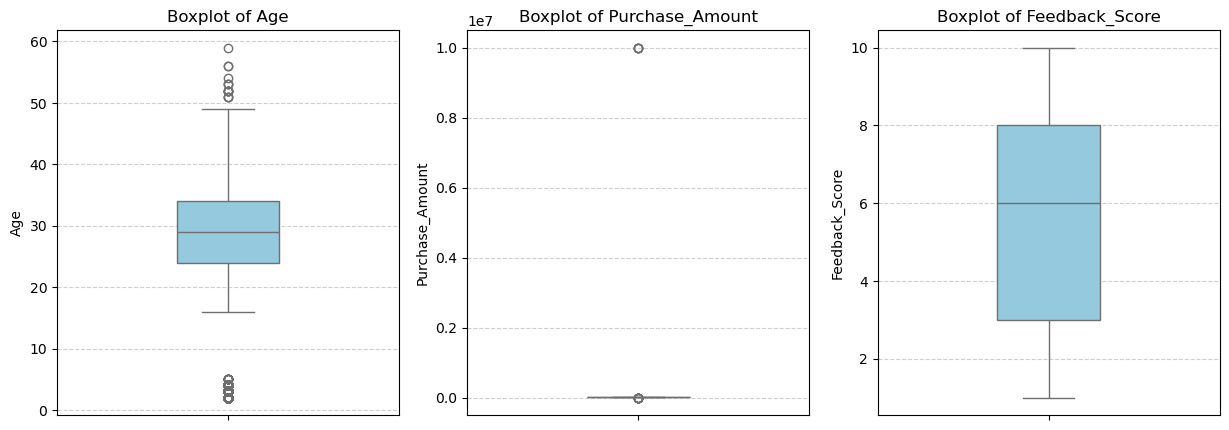

In [56]:
cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y = df[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.grid(axis='y', linestyle = '--', alpha=0.6)

### Calculating z-scores

In [57]:
from scipy import stats

In [58]:
stats.zscore(df[['Age', 'Purchase_Amount']])

array([[-1.02355759, -0.04068325],
       [ 0.85119844, -0.02017782],
       [-0.03684389, -0.02345689],
       ...,
       [ 0.75252707, -0.03400497],
       [-0.23418663, -0.00672114],
       [-0.332858  , -0.02556951]], shape=(10000, 2))

In [59]:
z_scores = np.abs(stats.zscore(df[['Age', 'Purchase_Amount']]))

In [60]:
# Display rows with >3 z-score
df[(z_scores > 3).any(axis = 1)]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
4516,CUST14517,Sneha Singh,Male,24,Delhi,2020-05-11,2025-02-17,9999999.0,1.0,sneha.singh516@gmail.com,9992423649,India
5628,CUST15629,Priya Yadav,Female,24,Kolkata,2022-07-06,2024-05-28,9999999.0,10.0,priya.yadav628@gmail.com,9315410059,India
8178,CUST18179,Vikram Verma,Male,31,Mumbai,2018-09-29,2024-05-08,9999999.0,4.0,vikram.verma178@gmail.com,9259159854,India
8575,CUST18576,Vivaan Patel,Male,16,Delhi,2020-08-19,2024-04-15,9999999.0,4.0,vivaan.patel575@gmail.com,9224916130,India
8880,CUST18881,Isha Agarwal,Female,59,Kolkata,2022-03-29,2024-10-10,5000.0,6.0,isha.agarwal880@gmail.com,9822165562,India


In [61]:
# Saving the rows with <3 z-score/ with no major outliers
df_clean = df[~(z_scores > 3).any(axis = 1)]

In [62]:
# Cleaned data shape
df_clean.shape

(9995, 12)

## 9. Exporting the cleaned dataset in csv format

In [63]:
df_clean.to_csv('cleaned_dataset.csv', index=False)